In [1]:
import os
import sys
import time
import intake
from tqdm import tqdm
import xarray as xr
import pandas as pd
import numpy as np
import pickle
from datetime import datetime
import metpy.calc as mpcalc
from metpy.units import units
import matplotlib.pyplot as plt
from dateutil.relativedelta import relativedelta


from dask.distributed import Client, LocalCluster

os.environ['WXSYSLIBDIR']='/g/data/gb02/mb0427/WxSysLib'
sys.path.append(os.environ['WXSYSLIBDIR'])
os.environ['SWTLIBDIR']='/home/565/mb0427/gdata-gb02/Australian_synoptic_weather_types'
sys.path.append(os.environ['SWTLIBDIR'])

In [18]:
START_YEAR = 1980
END_YEAR = 2020
OUTPUT_DIR = '/g/data/nf33/nk2247/wind_droughts/GC26_energy_synoptics/dev/wind_drought/'

In [13]:
SWTpath='/g/data/gb02/mb0427/Australian_synoptic_weather_types/'
clusters=xr.open_dataset(SWTpath+"SWT_climatology/SWT_climatology.nc")
clusters=clusters.sel(time=slice(datetime(START_YEAR,1,1),datetime(END_YEAR,12,31,23)))
clusters["time"] = clusters["time"] - np.timedelta64(12, "h")
SWTnames = clusters.SWTs

In [14]:
clusters=pd.read_csv(f"{SWTpath}SWT_climatology/SWT_climatology.csv")
times=[datetime.strptime(t,'%Y-%m-%d') for t in clusters.time.to_list()]
clusters['time']=times
clusters=clusters[clusters.time>=datetime(START_YEAR,1,1)]
clusters=clusters[clusters.time<=datetime(END_YEAR,12,31)]

In [2]:
DATA_DIR = '/g/data/nf33/nk2247/wind_droughts/GC26_energy_synoptics/data/output/era5_wind_drought_binary/'
cf_drought_file = f'{DATA_DIR}wind_drought_binary_cf_1980_2020.nc'
cf_drought = xr.open_dataset(cf_drought_file)

In [3]:
data = cf_drought['cf_drought_010']
cumulative = data.cumsum(dim='time')-data.cumsum(dim='time').where(data.values == 0).ffill(dim='time').fillna(0)

In [4]:
cumulative

<xarray.DataArray 'cf_drought_010' (time: 14976, lat: 141, lon: 181)> Size: 3GB
array([[[ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

       [[ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  1.,  1.],
        [ 0.,  0.,  0., ...,  1.,  1.,  1.],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

       [[ 0.,  0.,  0., ...,  1.,  1.,  1.],
        [ 0.,  0.,  0., ...,  1.,  2.,  2.],
        [ 0.,  0.,  0., ...,  2.,  2.,  2.],
        ...,
...
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

       [[11., 11., 11., ..., 17., 17., 17.],
        [11., 11., 11., ..., 17., 17., 17.],
        [20., 11., 11., ..., 17., 17., 28.],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

       [[12., 12., 12., ..., 18., 18., 18.],
        [12., 12., 12., ..., 18., 18., 18.],
        [21., 12., 12., ..., 18., 18., 29.],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]]], shape=(14976, 141, 181))
Coordinates:
  * time     (time) datetime64[ns] 120kB 1980-01-01 1980-01-02 ... 2020-12-31
  * lat      (lat) float32 564B -10.0 -10.25 -10.5 -10.75 ... -44.5 -44.75 -45.0
  * lon      (lon) float32 724B 110.0 110.2 110.5 110.8 ... 154.5 154.8 155.0
Attributes:
    long_name:    Binary wind drought flag, capacity factor < 0.10
    description:  1 if the day belongs to an episode of >= 3 consecutive days...
    units:        1
    threshold:    CF < 0.10

In [7]:
match = cumulative.shift({'time':-1}) # Shift time back by one
drought_duration = cumulative.where((match==0) & (cumulative != 0))
del match

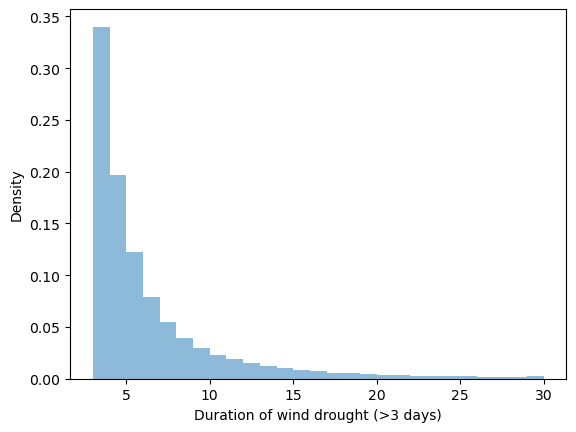

In [10]:
drought_duration.plot.hist(bins=[i for i in range(3,31)], density=True, alpha=0.5)
plt.ylabel('Density')
plt.xlabel('Duration of wind drought (>3 days)')
plt.show()

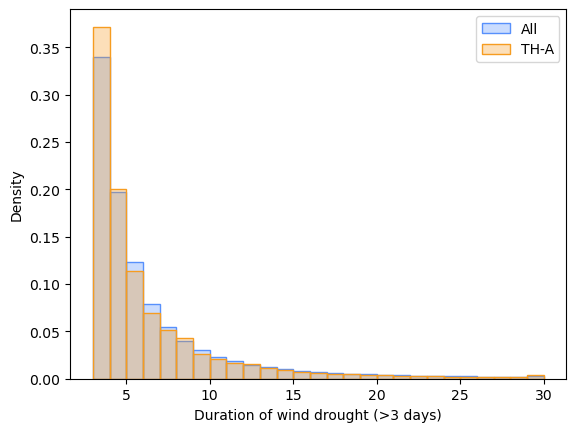

In [16]:
SWT_name = 'TH-A'
SWT_i = clusters[clusters.assigned_SWT == SWT_name]
ds_i = drought_duration.sel(time=SWT_i.time.to_list())
drought_duration.plot.hist(bins=[i for i in range(3,31)], density=True, color='#5790FC50', edgecolor='#5790FC', label='All')
ds_i.plot.hist(bins=[i for i in range(3,31)], density=True,  color='#F69C2050', edgecolor='#F69C20', label=SWT_name)
plt.ylabel('Density')
plt.xlabel('Duration of wind drought (>3 days)')
plt.legend()

100%|██████████| 30/30 [00:48<00:00,  1.63s/it]


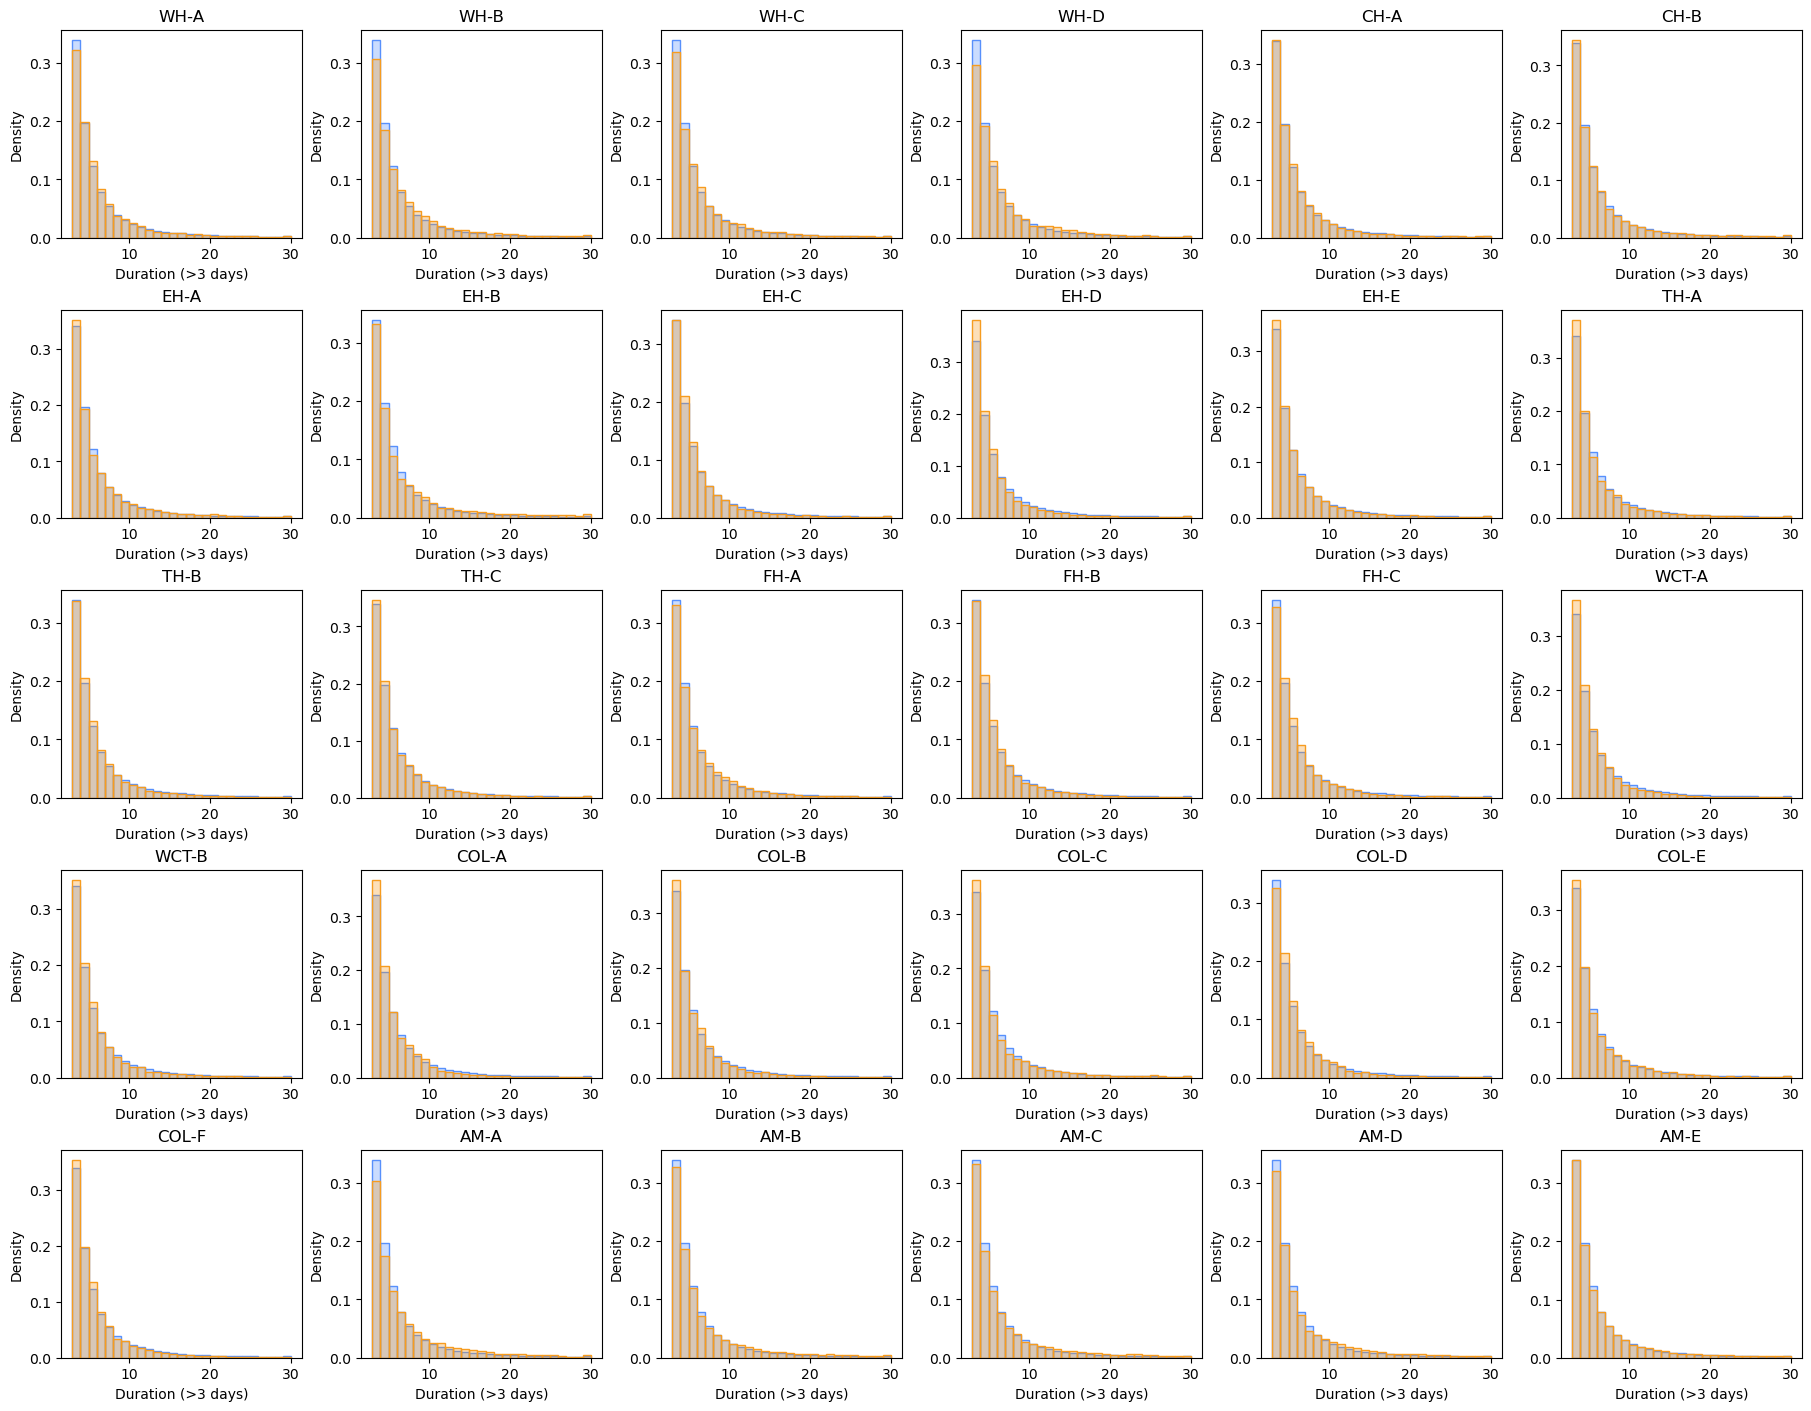

In [19]:
var = 'hist_drought_duration'
name = f'{START_YEAR}_{END_YEAR}_{var}_SWT'
bins = [i for i in range(3,31)]

fig, axes = plt.subplots(5, 6, figsize=(18, 14), constrained_layout=True)
axes = axes.flatten()

mappable = None

for i, SWTname in enumerate(tqdm(SWTnames)):
    ax = axes[i]
    SWT_i = clusters[clusters.assigned_SWT == SWTname]
    ds_i = drought_duration.sel(time=SWT_i.time.to_list())
    drought_duration.plot.hist(ax=ax, bins=bins, density=True, color='#5790FC50', edgecolor='#5790FC')
    ds_i.plot.hist(ax=ax, bins=bins, density=True,  color='#F69C2050', edgecolor='#F69C20')
    ax.set_title(str(SWTname.item()))
    ax.set_ylabel('Density')
    ax.set_xlabel('Duration (>3 days)')

for j in range(len(SWTnames), len(axes)):
    axes[j].set_visible(False)


outfile=f"{OUTPUT_DIR}/{name}.png"
fig.savefig(outfile, dpi=600)
plt.show()

100%|██████████| 30/30 [02:16<00:00,  4.53s/it]


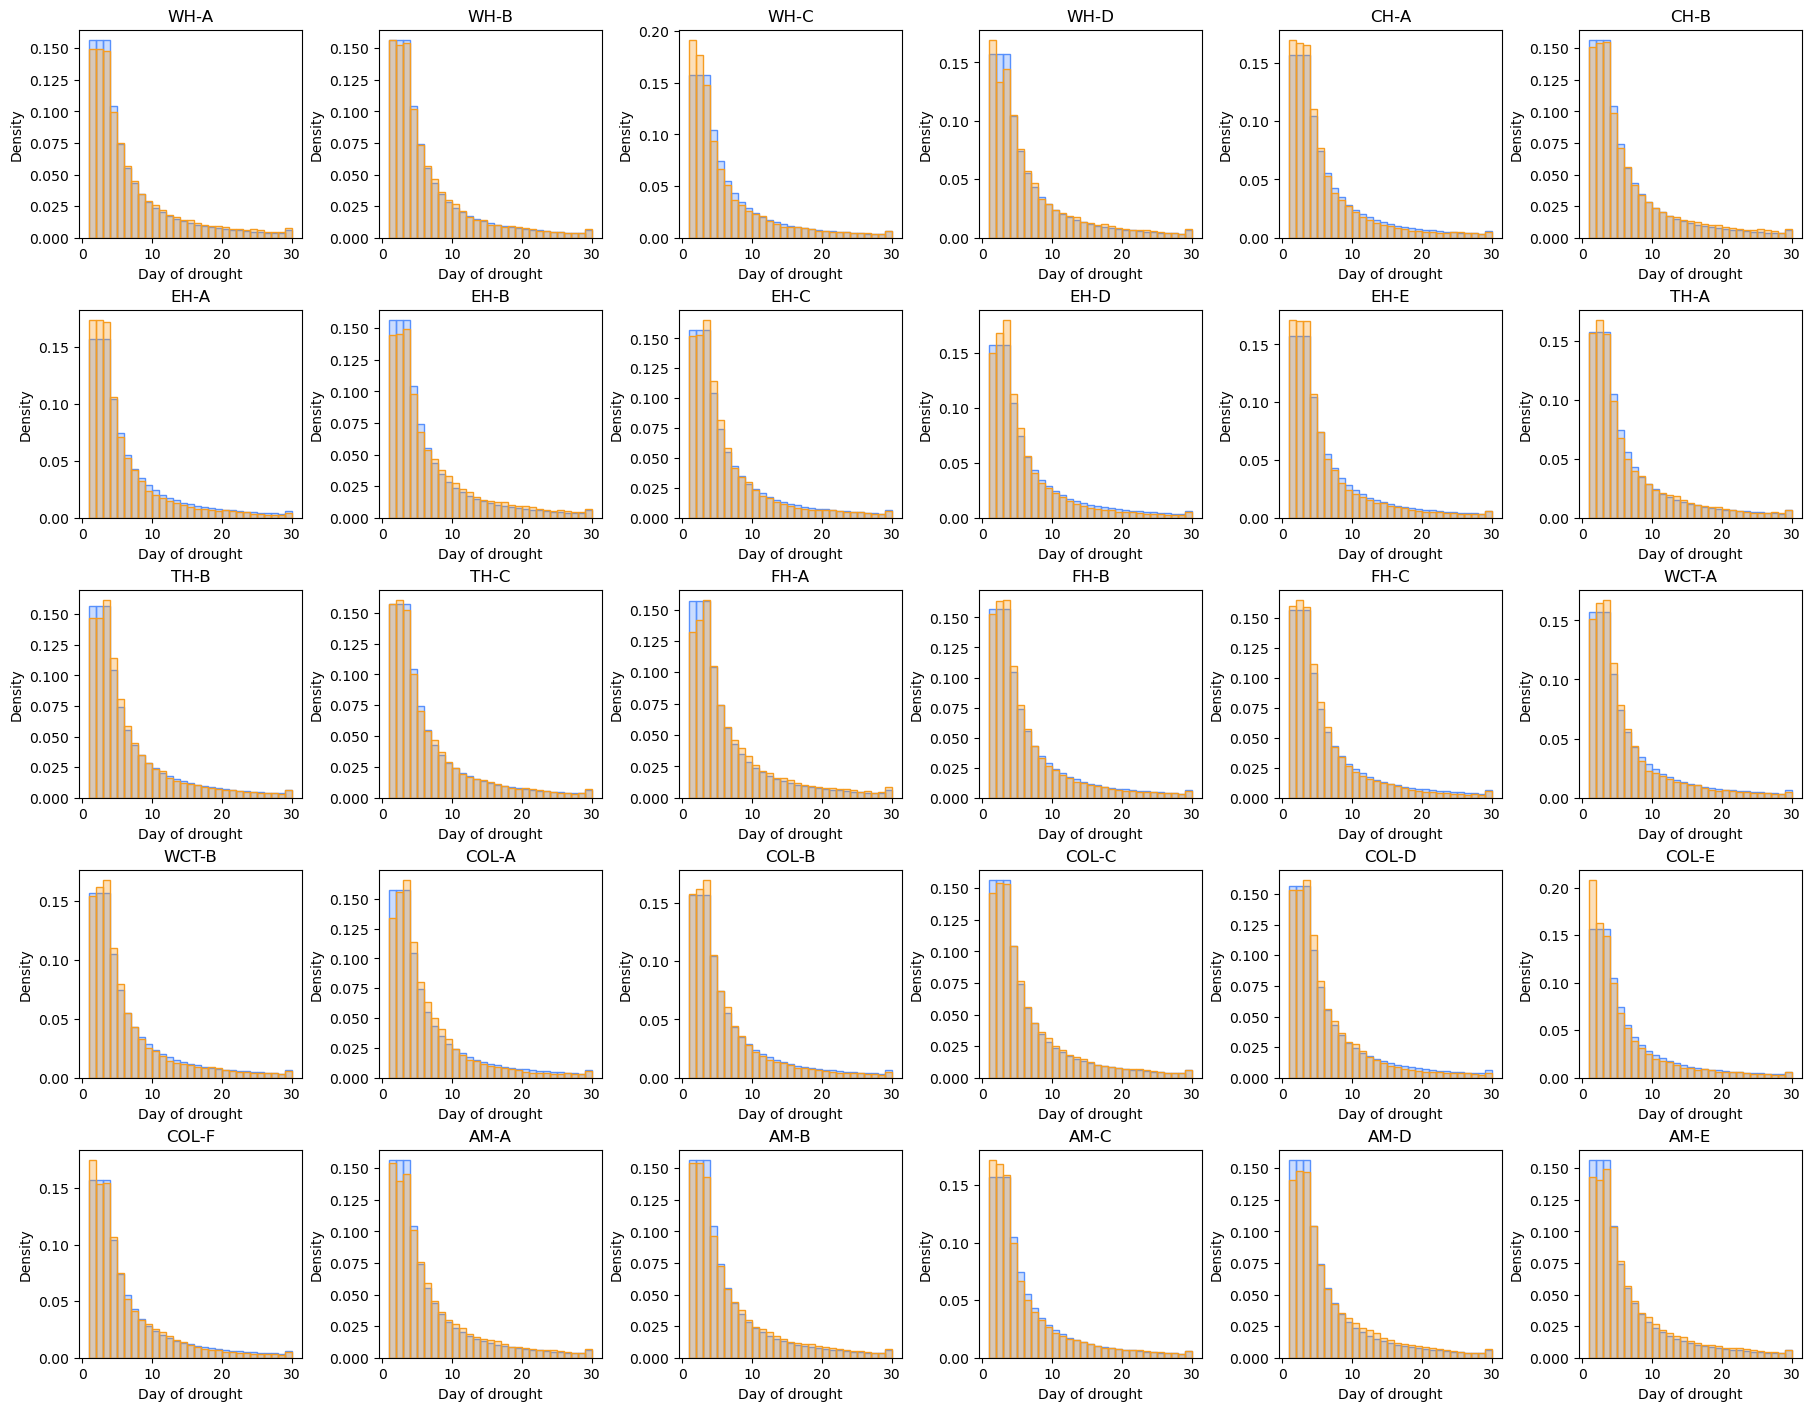

In [38]:
var = 'hist_SWT_on_day_of_drought'
name = f'{START_YEAR}_{END_YEAR}_{var}'
bins = [i for i in range(1,31)]

fig, axes = plt.subplots(5, 6, figsize=(18, 14), constrained_layout=True)
axes = axes.flatten()

mappable = None

for i, SWTname in enumerate(tqdm(SWTnames)):
    ax = axes[i]
    SWT_i = clusters[clusters.assigned_SWT == SWTname]
    ds_i = cumulative.sel(time=SWT_i.time.to_list())
    cumulative.plot.hist(ax=ax, bins=bins, density=True, color='#5790FC50', edgecolor='#5790FC')
    ds_i.plot.hist(ax=ax, bins=bins, density=True,  color='#F69C2050', edgecolor='#F69C20')
    ax.set_title(str(SWTname.item()))
    ax.set_ylabel('Density')
    ax.set_xlabel('Day of drought')

for j in range(len(SWTnames), len(axes)):
    axes[j].set_visible(False)


outfile=f"{OUTPUT_DIR}/{name}.png"
fig.savefig(outfile, dpi=600)
plt.show()

100%|██████████| 30/30 [00:23<00:00,  1.25it/s]


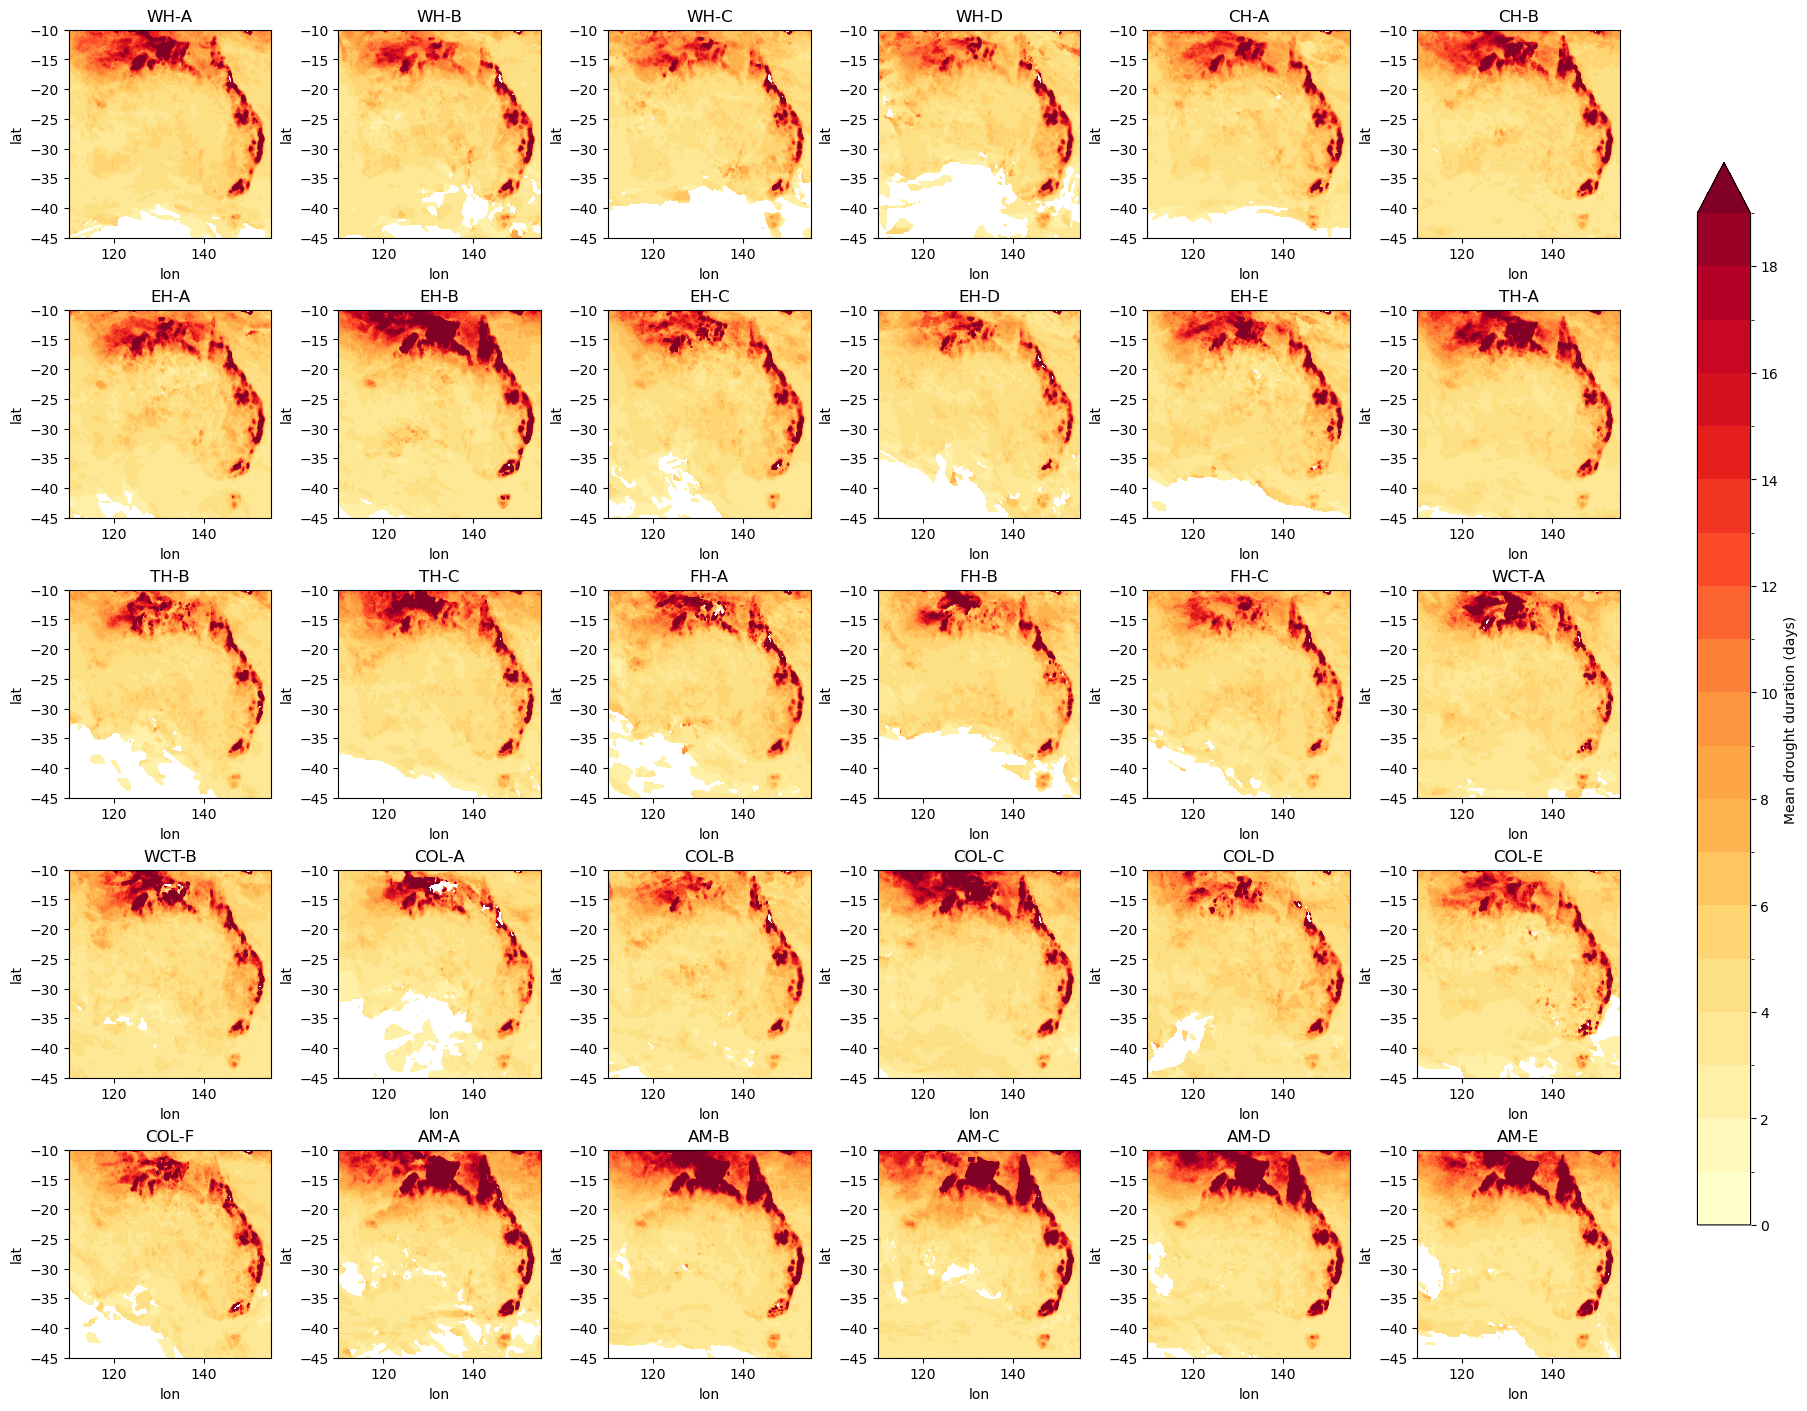

In [20]:
var = 'mean_drought_duration'
name = f'{START_YEAR}_{END_YEAR}_{var}_SWT'
levels = np.arange(0, 20)

fig, axes = plt.subplots(5, 6, figsize=(18, 14), constrained_layout=True)
axes = axes.flatten()

mappable = None

for i, SWTname in enumerate(tqdm(SWTnames)):
    SWT_i = clusters[clusters.assigned_SWT == SWTname]
    ds_i = drought_duration.sel(time=SWT_i.time.to_list())
    ds_i_clim = ds_i.mean(dim='time')

    ax = axes[i]
    mappable = ds_i_clim.plot.contourf(
        ax=ax,
        levels=levels,
        cmap="YlOrRd",
        vmin=levels.min(),
        vmax=levels.max(),
        add_colorbar=False
    )
    ax.set_title(str(SWTname.item()))

for j in range(len(SWTnames), len(axes)):
    axes[j].set_visible(False)

fig.colorbar(mappable, ax=axes, shrink=0.8, label="Mean drought duration (days)")

outfile=f"{OUTPUT_DIR}/{name}.png"
fig.savefig(outfile, dpi=600)
plt.show()

100%|██████████| 30/30 [01:05<00:00,  2.17s/it]


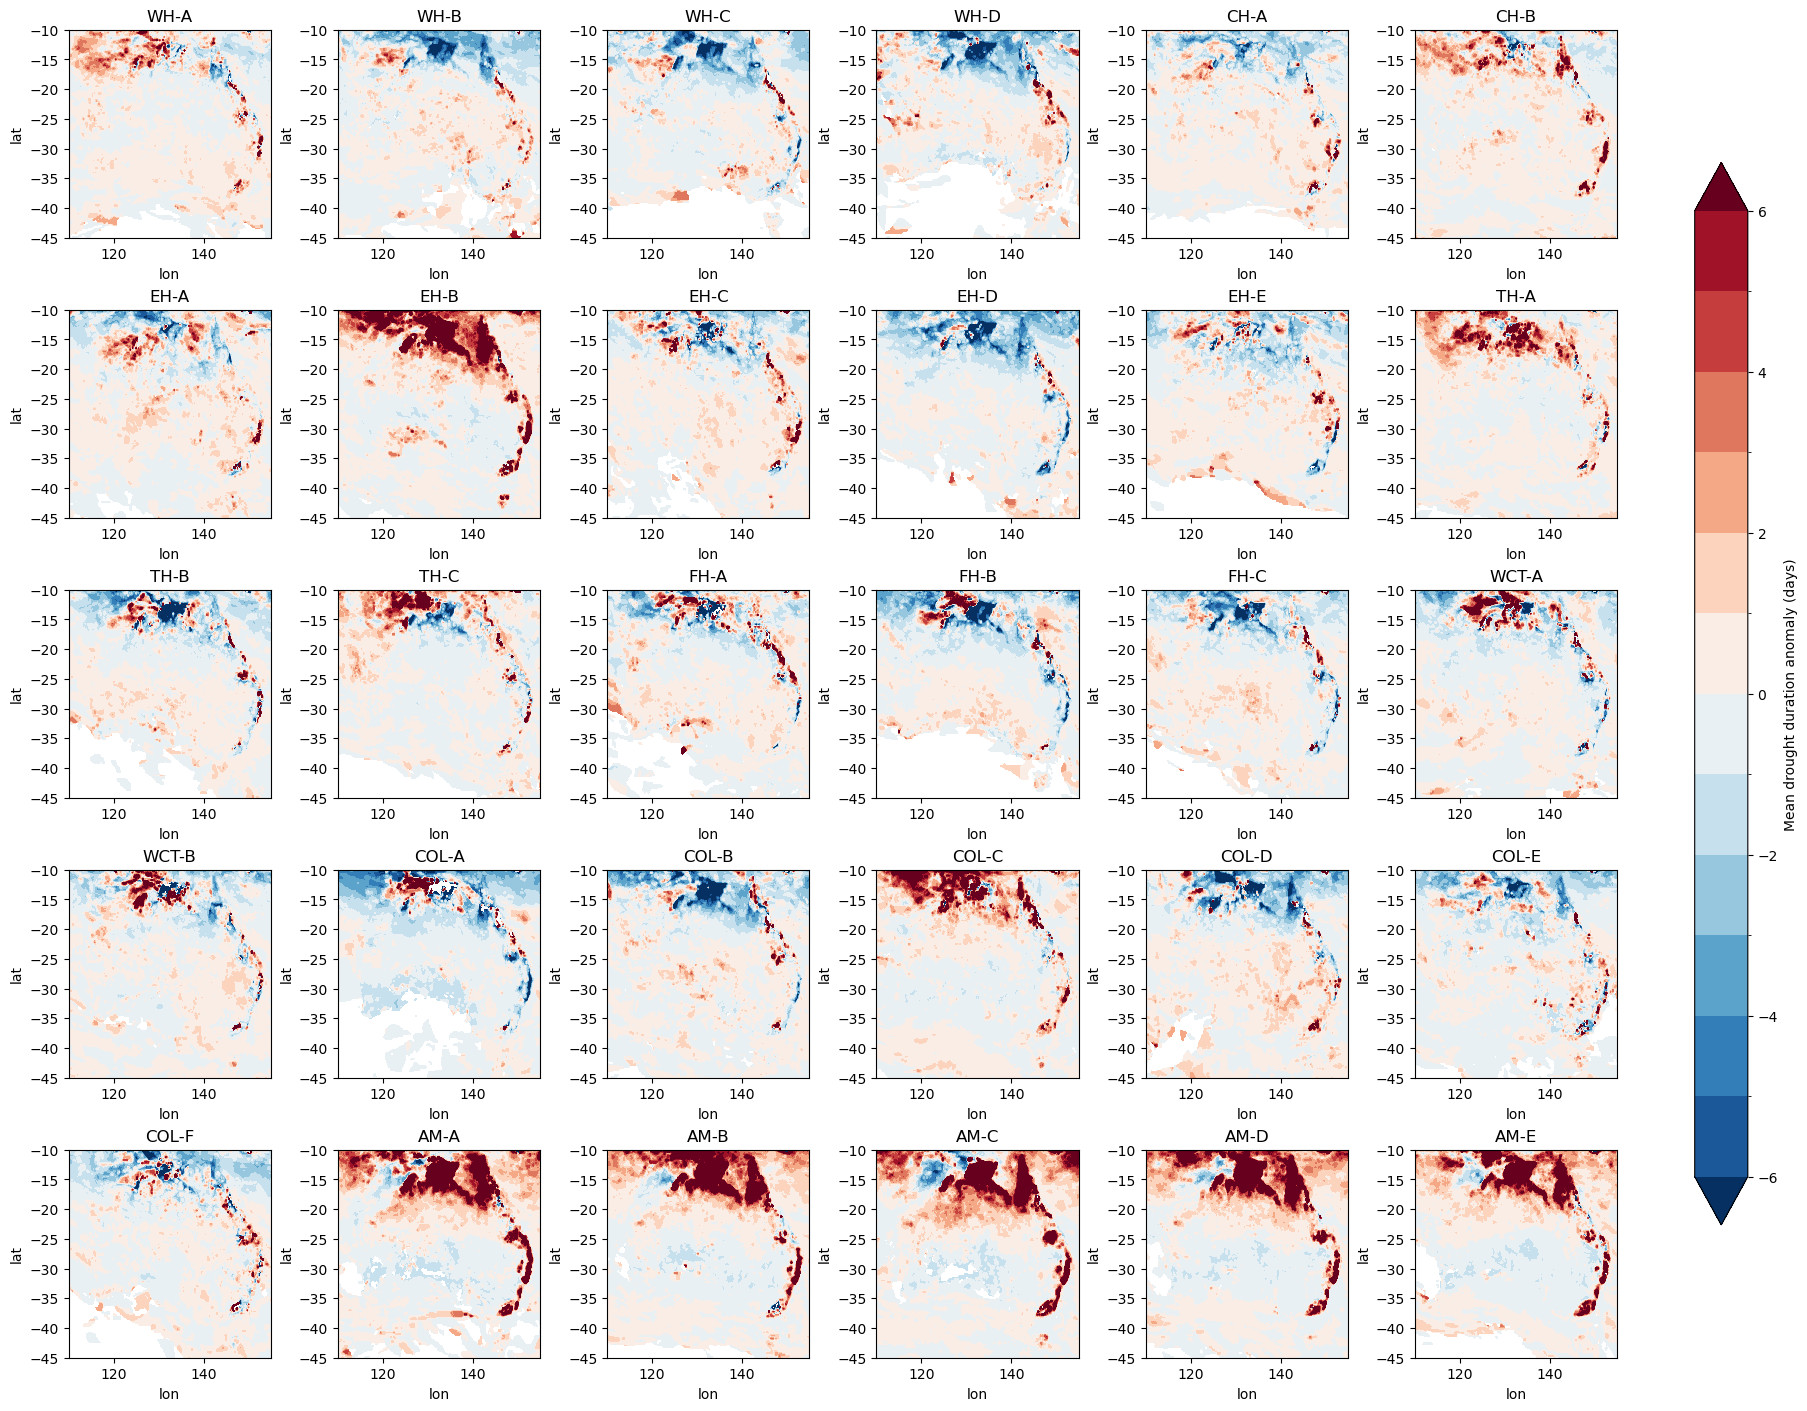

In [23]:
var = 'mean_drought_duration_anomaly'
name = f'{START_YEAR}_{END_YEAR}_{var}_SWT'
levels = np.arange(-6, 7)

fig, axes = plt.subplots(5, 6, figsize=(18, 14), constrained_layout=True)
axes = axes.flatten()

mappable = None

for i, SWTname in enumerate(tqdm(SWTnames)):
    SWT_i = clusters[clusters.assigned_SWT == SWTname]
    ds_i = drought_duration.sel(time=SWT_i.time.to_list())
    ds_i_clim = ds_i.mean(dim='time') - drought_duration.mean(dim='time')

    ax = axes[i]
    mappable = ds_i_clim.plot.contourf(
        ax=ax,
        levels=levels,
        cmap="RdBu_r",
        vmin=levels.min(),
        vmax=levels.max(),
        add_colorbar=False
    )
    ax.set_title(str(SWTname.item()))

for j in range(len(SWTnames), len(axes)):
    axes[j].set_visible(False)

fig.colorbar(mappable, ax=axes, shrink=0.8, label="Mean drought duration anomaly (days)")

outfile=f"{OUTPUT_DIR}/{name}.png"
fig.savefig(outfile, dpi=600)
plt.show()

100%|██████████| 30/30 [01:03<00:00,  2.11s/it]


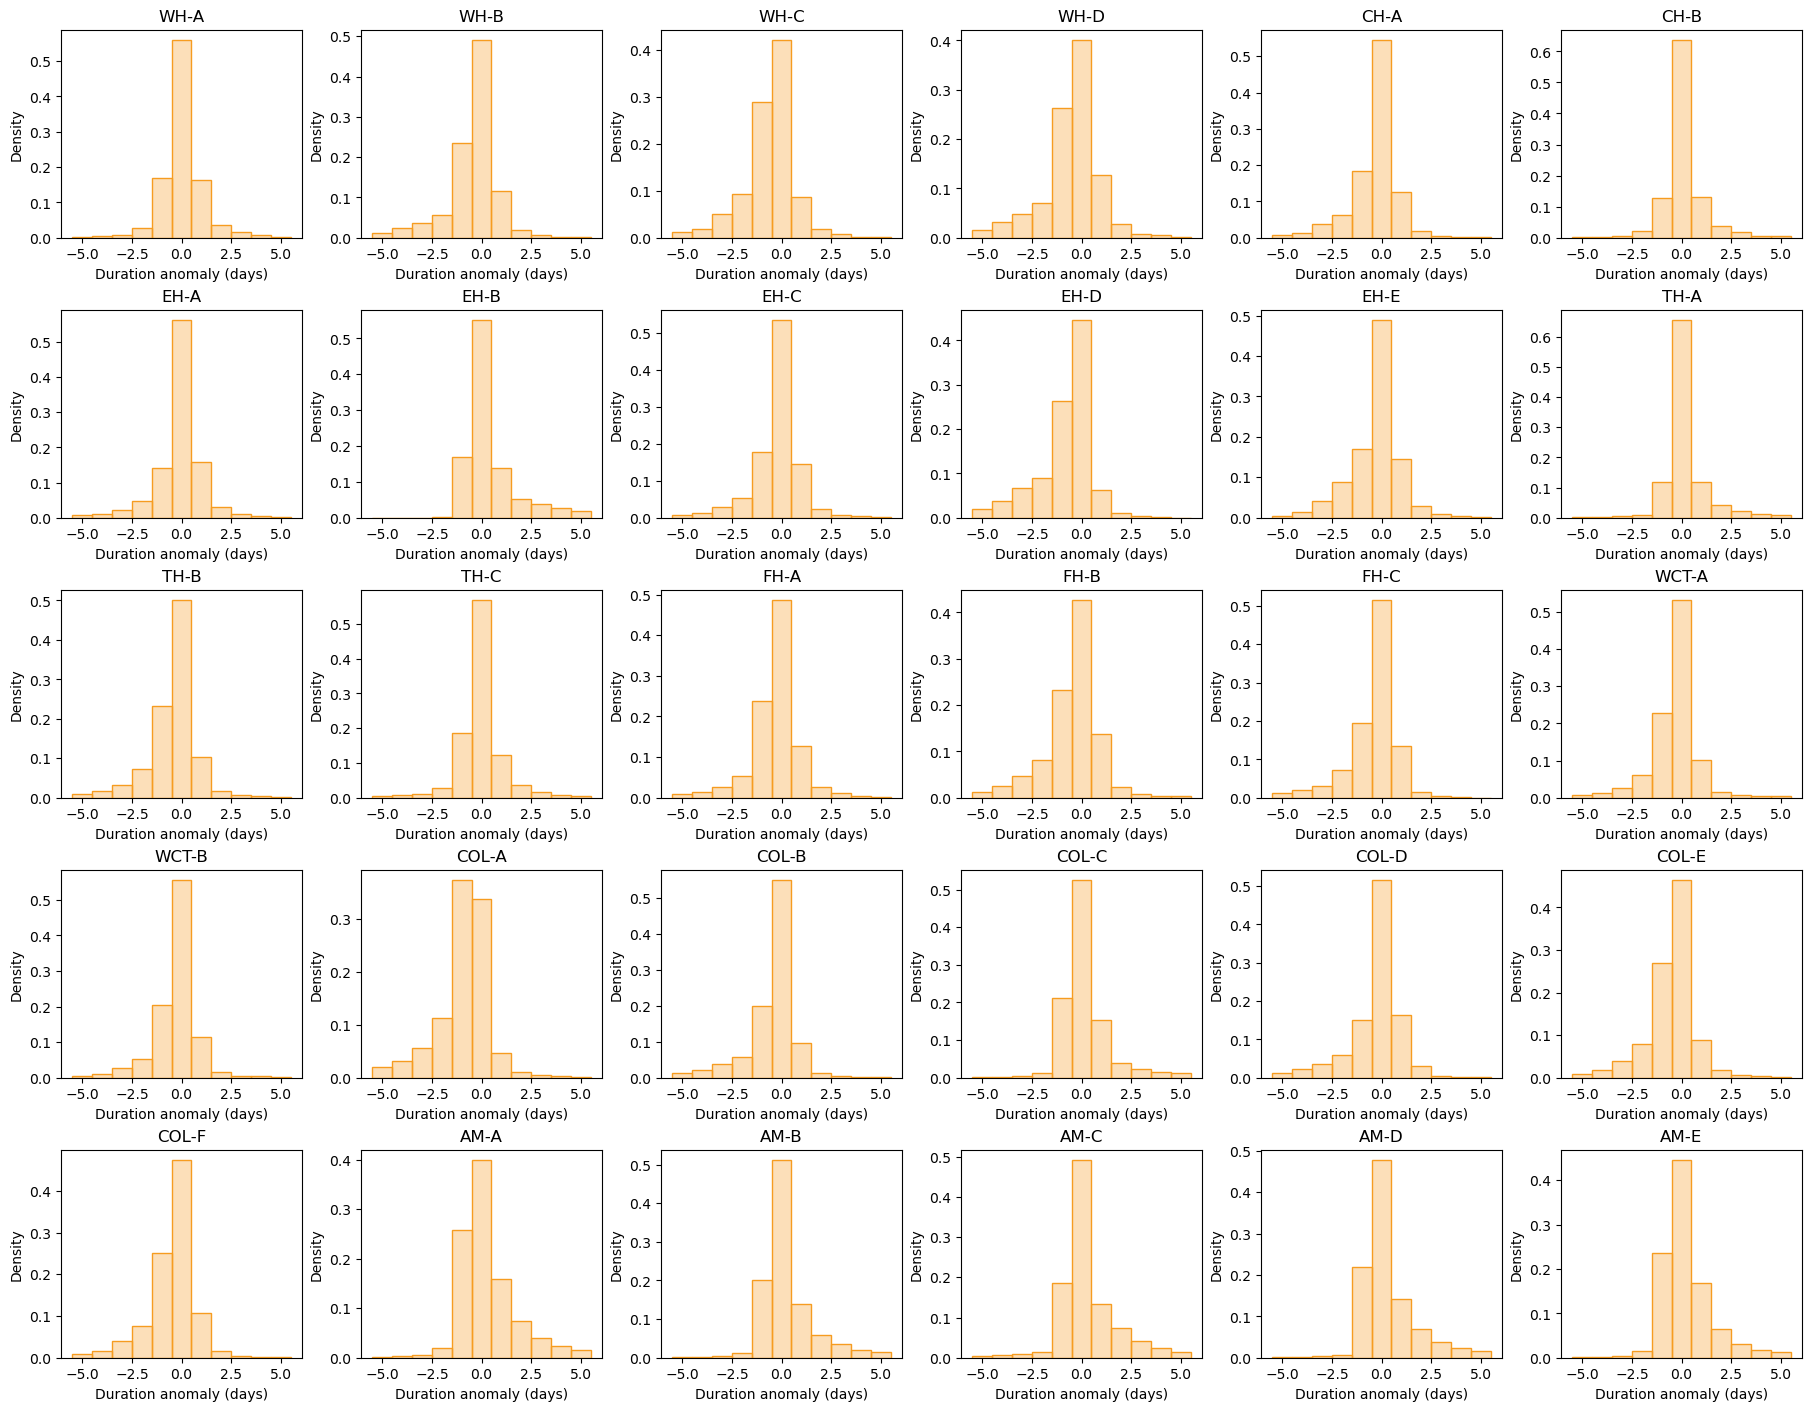

In [37]:
var = 'hist_drought_duration_anomaly'
name = f'{START_YEAR}_{END_YEAR}_{var}_SWT'
bins = np.arange(-5.5,6)

fig, axes = plt.subplots(5, 6, figsize=(18, 14), constrained_layout=True)
axes = axes.flatten()

mappable = None

for i, SWTname in enumerate(tqdm(SWTnames)):
    ax = axes[i]
    SWT_i = clusters[clusters.assigned_SWT == SWTname]
    ds_i = drought_duration.sel(time=SWT_i.time.to_list())
    anomaly_i = ds_i.mean(dim='time') - drought_duration.mean(dim='time')
    anomaly_i.plot.hist(ax=ax, bins=bins, density=True,  color='#F69C2050', edgecolor='#F69C20')
    ax.set_title(str(SWTname.item()))
    ax.set_ylabel('Density')
    ax.set_xlabel('Duration anomaly (days)')

for j in range(len(SWTnames), len(axes)):
    axes[j].set_visible(False)


outfile=f"{OUTPUT_DIR}/{name}.png"
fig.savefig(outfile, dpi=600)
plt.show()